In this notebook, I want to try to include different soil types and make it easy to decide how many layers you want

In [1]:
from dolfinx import default_scalar_type
from dolfinx.fem import (
    Constant,
    Function,
    Expression,
    functionspace,
    assemble_scalar,
    dirichletbc,
    form,
    locate_dofs_topological,
    locate_dofs_geometrical,
    extract_function_spaces,
)
from dolfinx.fem.petsc import (
    LinearProblem, 
    NonlinearProblem,
    create_matrix, 
    create_vector, 
)
from dolfinx.io import XDMFFile
from dolfinx.mesh import (
    create_unit_square,
    locate_entities,
    meshtags,
    compute_midpoints,
)
from dolfinx.plot import vtk_mesh

from mpi4py import MPI
import ufl
from ufl import (
    FacetNormal,
    Measure,
    SpatialCoordinate,
    TestFunction,
    TrialFunction,
    div,
    dot,
    dx,
    grad,
    inner,
    exp,
    sqrt,
    ln,
    lhs,
    rhs,
    conditional,
    derivative,
)

from petsc4py import PETSc
import numpy as np
import pyvista

from visualization_fct import *

In [2]:
def create_quad_domain(comm, nx, ny, p0, p1, p2, p3):
    """
    Create a domain defined by four corner points.

    Args:
        comm (mpi4py.MPI.Intracomm): MPI communicator
        nx (int): number of cells in x-direction
        ny (int): number of cells in y-direction
        p0 (np.array): x and y coordinates of the bottom-left corner point
        p1 (np.array): x and y coordinates of the bottom-right corner point
        p2 (np.array): x and y coordinates of the top-right corner point
        p3 (np.array): x and y coordinates of the top-left corner point

    Returns:
        dolfinx.mesh: Domain defined by the corner points.
    """

    mesh = create_unit_square(comm, nx, ny)

    x = mesh.geometry.x
    xi = x[:, 0]
    eta = x[:, 1]

    x[:, :2] = (
        np.outer((1-xi)*(1-eta), p0) +
        np.outer(xi*(1-eta), p1) +
        np.outer(xi*eta, p2) +
        np.outer((1-xi)*eta, p3)
    )
    return mesh

2026-04-30 15:36:42.403 (   0.889s) [    777C1241A600]vtkXOpenGLRenderWindow.:1458  WARN| bad X server connection. DISPLAY=


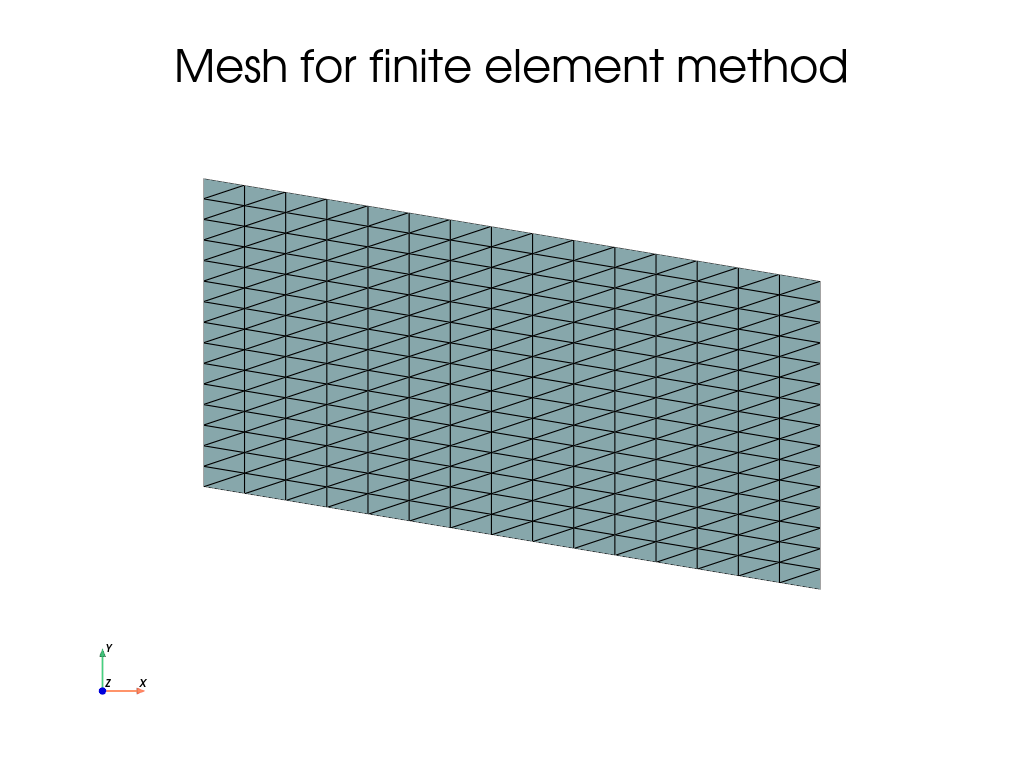

In [3]:
from visualization_fct import plot_mesh2
# Generate domain from four corner points
P0 = np.array([0, 0])
P1 = np.array([6, -1])
P2 = np.array([6, 2])
P3 = np.array([0, 3])
domain = create_quad_domain(MPI.COMM_WORLD, 15, 15, P0, P1, P2, P3)
plot_mesh2(domain)

### Define variational problem

First try: two soils, loam underneath sand

In [4]:
V = functionspace(domain, ("CG", 1))
v = TestFunction(V)
x = SpatialCoordinate(domain)

slope = (P1[1]-P0[1])/(P1[0]-P0[0]) # slope of bottom and top boundary

In [5]:
# Define parameters for each layer (layer 1: loam, layer 2: sand) (from bottom to top)

layer_params = {
    1: {"alpha": 3.6, "N": 1.56, "theta_r": 0.078, "theta_s": 0.43, "Ks": 2.89e-6, "locator": lambda x: x[1] <= slope*x[0] + P3[1]/2 + 1e-14},
    2: {"alpha": 14.5, "N": 2.68, "theta_r": 0.045, "theta_s": 0.43, "Ks": 8.25e-5, "locator": lambda x: x[1] > slope*x[0] + P3[1]/2 - 1e-14},
}



In [6]:
tdim = domain.topology.dim
all_cells = np.arange(domain.topology.index_map(tdim).size_local, dtype=np.int32)
cell_midpoints = compute_midpoints(domain, tdim, all_cells)
cell_markers = np.full_like(all_cells, 0, dtype=np.int32)
for i, pts in enumerate(cell_midpoints):
    for key, value in layer_params.items():
        if value["locator"](pts):
            cell_markers[i] = key

cell_tag = meshtags(domain, tdim, all_cells, cell_markers)

#### Just some debugging here

In [7]:
#all_cells = np.arange(domain.topology.index_map(domain.topology.dim).size_local)
tagged_cells = np.hstack([cell_tag.find(key) for key in layer_params.keys()])
untagged_cells = np.setdiff1d(all_cells, tagged_cells)
print(f"Untagged cells: {untagged_cells}, {len(untagged_cells)}")

midpts = compute_midpoints(domain, domain.topology.dim, untagged_cells)

Untagged cells: [], 0


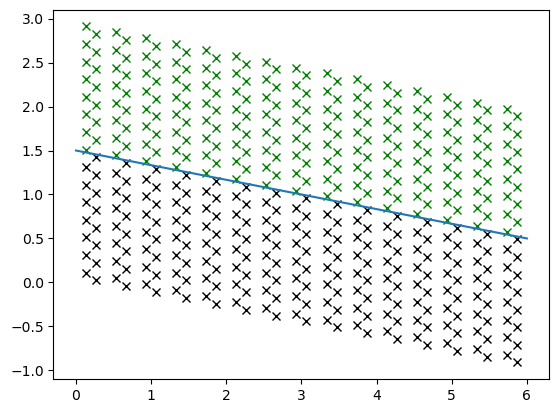

In [8]:
midpts1 = compute_midpoints(domain, domain.topology.dim, cell_tag.find(1))
midpts2 = compute_midpoints(domain, domain.topology.dim, cell_tag.find(2))
plt.plot(midpts1[:,0], midpts1[:,1], "x", color="black")
plt.plot(midpts2[:,0], midpts2[:,1], 'x', color="green")
plt.plot(np.linspace(0,6,100), slope*np.linspace(0,6,100)+ P3[1]/2, '-')
plt.plot(midpts[:,0], midpts[:,1], 'x', color="red")

### Define parametrizations

In [9]:

def Saturation(u, alpha, N):
    eps = 1e-8
    u = conditional(u > eps, u, eps) # only use 'safe' values > 0
    a1 = 1 + exp(ln(alpha * u)*N)
    exp1 = (1 - N) / N
    S = exp(ln(a1)*exp1)
    return S

def k(u, alpha, N, Ks):
    S = Saturation(u, alpha, N)
    m = N / (N-1)
    a1 = 1 - exp(ln(S)*m)
    a2 = 1 - exp(ln(a1) / m)
    k = sqrt(S) * a2 ** 2
    return k*Ks

### Define custom integration measures ds
Following https://jsdokken.com/dolfinx-tutorial/chapter3/robin_neumann_dirichlet.html <br>
Define $\Gamma_{bed}$ to be boundary 1, $\Gamma_D$ boundary 2 (where we assume the groundwater table is at 0), $\Gamma_{out}$ is boundary 3 and $\Gamma_{in}$ boundary 4.

In [10]:
# Boundary conditions

# Define the gw table at the right boundary to be below 0.
def on_dirichlet(x):
    return np.logical_and(np.isclose(x[0], P1[0]), x[1] <= 0)
def gamma_out(x):
    return np.logical_and(np.isclose(x[0], P1[0]), x[1] >= 0)
def gamma_in(x):
    return np.isclose(x[1], slope*x[0]+P3[1])
def bottom(x):
    return np.isclose(x[1], slope*x[0])
def gamma_bed(x):
    return np.logical_or(bottom(x), np.isclose(x[0], 0))

In [11]:
boundaries = [
    (1, gamma_bed),
    (2, on_dirichlet),
    (3, gamma_out),
    (4, gamma_in)
]

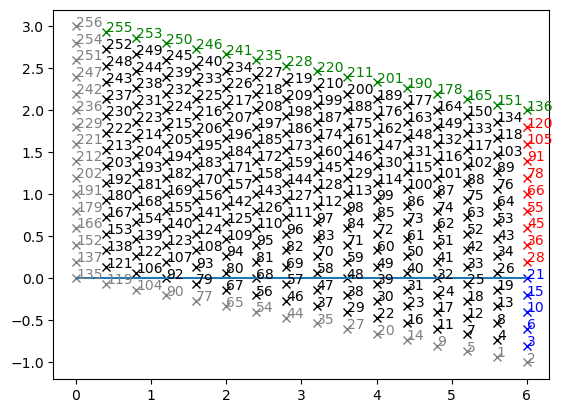

In [12]:
# Check, if the right boundaries are identified
pts = domain.geometry.x # mesh coordinates of the vertices shape=(num_points, 3)
pts = np.array(pts)
import matplotlib.pyplot as plt
for i, p in enumerate(pts):
    i += 1
    if gamma_bed(p):
        c = "grey"
    elif gamma_in(p):
        c = "green"
    elif gamma_out(p):
        c = "red"
    elif on_dirichlet(p):
        c = "blue"
    else:
        c = "black"
    plt.plot(p[0], p[1], 'x', color=c)
    plt.annotate(str(i), (p[0], p[1]), color=c)
plt.hlines(0, min(pts[:,0]), max(pts[:,0]))

In [13]:
# We now loop through all the boundary conditions and create MeshTags identifying the facets for each boundary condition.
facet_indices, facet_markers = [], []
fdim = domain.topology.dim - 1
for marker, locator in boundaries:
    facets = locate_entities(domain, fdim, locator) # find boundary facet
    facet_indices.append(facets)
    facet_markers.append(np.full_like(facets, marker))
facet_indices = np.hstack(facet_indices).astype(np.int32) # make array of arrays into single array
facet_markers = np.hstack(facet_markers).astype(np.int32)
sorted_facets = np.argsort(facet_indices)
facet_tag = meshtags(
    domain, fdim, facet_indices[sorted_facets], facet_markers[sorted_facets]
) # each boundary facet gets identified with its boundary condition

domain.topology.create_connectivity(fdim, domain.topology.dim) # connect facets to cells

In [14]:
# Create custom integration measure
ds = Measure("ds", domain, subdomain_data=facet_tag)

In [15]:
# Create general boundary condition class
class BoundaryCondition:
    def __init__(self, type, marker, values):
        self._type = type
        if type == "Dirichlet":
            facets = facet_tag.find(marker)
            dofs = locate_dofs_topological(V, fdim, facets)
            self._bc = dirichletbc(PETSc.ScalarType(values), dofs, V)
        elif type == "Neumann":
            self._bc = inner(values, v) * ds(marker)
        else:
            raise TypeError("Unknown boundary condition: {0:s}".format(type))

    @property
    def bc(self):
        return self._bc

    @property
    def type(self):
        return self._type

In [16]:
# Define boundary conditions
c_in = 2e-9 # recharge
boundary_conditions = [
    BoundaryCondition("Neumann", 1, Constant(domain, default_scalar_type(0))),
    BoundaryCondition("Dirichlet", 2, 0),
    BoundaryCondition("Neumann", 3, Constant(domain, default_scalar_type(0))),
    BoundaryCondition("Neumann", 4, Constant(domain, default_scalar_type(c_in)))
]

In [17]:
bcs = []
for condition in boundary_conditions:
    if condition.type == "Dirichlet":
        bcs.append(condition.bc)

### Newton iteration

In [18]:
# Initial guess: hydrostatic (h_c = height above gw table)
def u_ini(x):
    return np.maximum(x[1], 0)

v = TestFunction(V)
uh = Function(V)
uh.interpolate(u_ini)
x = SpatialCoordinate(domain)
bc = bcs

# define custom integration measure
dx = Measure("dx", domain, subdomain_data=cell_tag)
F = - v*c_in*ds(4)

for key, value in layer_params.items():
    conductivity = k(uh, value["alpha"], value["N"], value["Ks"])
    F += inner(conductivity * grad(x[1] - uh), grad(v)) * dx(key)

residual = form(F)
J = derivative(F, uh)
jacobian = form(J)

# Setup of iteration-independent structures
A = create_matrix(jacobian)
L = create_vector(extract_function_spaces(residual))

# Create linear solver and vector for delta_u
solver = PETSc.KSP().create(domain.comm)
solver.setType("preonly")
solver.getPC().setType("lu")
solver.getPC().setFactorSolverType("mumps")
solver.setErrorIfNotConverged(True)

solver.setOperators(A)
du = Function(V)


In [19]:
petsc_options = {
    "snes_type": "newtonls",
    "snes_linesearch_type": "bt",
    "snes_atol": 1e-10,
    "snes_rtol": 1e-10,
    "snes_monitor": None,
    "ksp_error_if_not_converged": True,
    "ksp_type": "preonly",
    "ksp_rtol": 1e-10,
    "ksp_monitor": None,
    "pc_type": "lu",
    "pc_factor_mat_solver_type": "mumps",
}

problem = NonlinearProblem(
    F,
    uh,
    bcs=bc,
    J=J,
    petsc_options=petsc_options,
    petsc_options_prefix="RichardsSNES_",
)



uh = problem.solve()
converged = problem.solver.getConvergedReason()
num_iter = problem.solver.getIterationNumber()
assert converged > 0, f"Solver did not converge, got {converged}."
print(
    f"Solver converged after {num_iter} iterations with converged reason {converged}."
)

  0 SNES Function norm 5.376620993686e-06
    Residual norms for RichardsSNES_ solve.
    0 KSP Residual norm 5.376620993686e-06
    1 KSP Residual norm 2.482437095608e-21
  1 SNES Function norm 5.372519119629e-06
    Residual norms for RichardsSNES_ solve.
    0 KSP Residual norm 5.372519119629e-06
    1 KSP Residual norm 1.819927058817e-19
  2 SNES Function norm 5.371377656077e-06
    Residual norms for RichardsSNES_ solve.
    0 KSP Residual norm 5.371377656077e-06
    1 KSP Residual norm 6.250335586997e-19
  3 SNES Function norm 5.360399940747e-06
    Residual norms for RichardsSNES_ solve.
    0 KSP Residual norm 5.360399940747e-06
    1 KSP Residual norm 1.034179158000e-19
  4 SNES Function norm 5.341984382685e-06
    Residual norms for RichardsSNES_ solve.
    0 KSP Residual norm 5.341984382685e-06
    1 KSP Residual norm 2.664884601359e-20
  5 SNES Function norm 5.221572578303e-06
    Residual norms for RichardsSNES_ solve.
    0 KSP Residual norm 5.221572578303e-06
    1 KSP R

#### Again some debugging

In [18]:
vol1 = form(1 * dx(1))
vol2 = form(1 * dx(2))
volume = assemble_scalar(vol1) + assemble_scalar(vol2)
volume

17.99999999999998

In [ ]:
# Assemble Jacobian
A = assemble_matrix(jacobian, bcs=bcs)
A.assemble()

# Check for zero rows/columns
print("Jacobian norm:", A.norm())
num_zero_rows = 0
for i in range(A.getSize()[0]):
    row = A.getRow(i)  # Returns (column_indices, values)
    if len(row[0]) == 0:  # If no non-zero entries, row is zero
        num_zero_rows += 1
print("Number of zero rows:", num_zero_rows)

Jacobian norm: nan
Number of zero rows: 0


### Plot solution

In [20]:
# Number of points along each edge
n = 15

# Create parameter space
x_int = np.linspace(0, 1, n)
y_int = np.linspace(0, 1, n)
x_int, y_int = np.meshgrid(x_int, y_int)

# Bilinear interpolation
x = (1 - x_int) * (1 - y_int) * P0[0] + x_int * (1 - y_int) * P1[0] + x_int * y_int * P2[0] + (1 - x_int) * y_int * P3[0]
y = (1 - x_int) * (1 - y_int) * P0[1] + x_int * (1 - y_int) * P1[1] + x_int * y_int * P2[1] + (1 - x_int) * y_int * P3[1]

# Combine into a grid of points
grid = np.column_stack((x.ravel(), y.ravel()))

# Evaluate u on grid
h = eval_fct_on_grid(grid, [uh], domain).reshape((n,n))
x = x.reshape((n,n))
z = y.reshape((n,n))


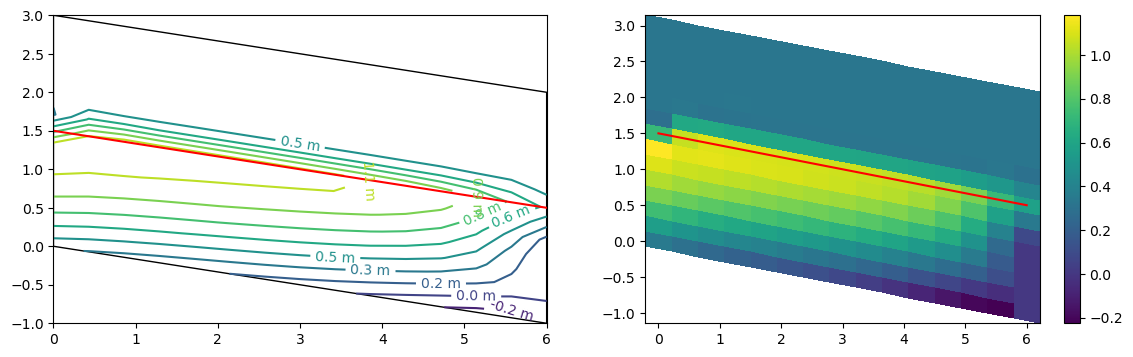

In [21]:
from matplotlib.patches import Polygon

fig, ax = plt.subplots(1,2, figsize=(14,4))
con = ax[0].contour(x, z, h, levels=10)
ax[0].clabel(con, fmt="%1.1f m")
# add black box around domain
polygon = Polygon([P1, P2, P3, P0], fill=False, edgecolor='black')
ax[0].add_patch(polygon)
# add line at layer interface
x_l = np.linspace(P0[0], P1[0], 100)
interface = slope*x_l+P3[1]/2
ax[0].plot(x_l, interface, color="red")

pmesh = ax[1].pcolormesh(x, z, h)
ax[1].plot(x_l, interface, color="red")
fig.colorbar(pmesh, ax = ax[1])



### Try to plot the water content

In [24]:
layer_params[2]["alpha"]

14.5

In [ ]:
saturation = Function(V)



saturation.interpolate(conditional(x[1]<= slope*x[0]+P3[1]/2 + 1e-14, Saturation(uh, layer_params[1]["alpha"], layer_params[1]["N"]), Saturation(uh, layer_params[2]["alpha"], layer_params[2]["N"])))

ValueError: Expecting condition as first argument.